# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [2]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.tail()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,97,C#,Major,82,67,77,8,0,12,5
952,Alone,Burna Boy,1,2022,11,4,782,2,96007391,27,...,90,E,Minor,61,32,67,15,0,11,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [4]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Features 
features = [
    'bpm',
    'key',
    'mode',
    'danceability_%',
    'energy_%',
    'speechiness_%',
    'acousticness_%'
]


spotify = df.dropna(subset=features + ['streams'])

spotify[features + ['track_name', 'artist(s)_name', 'streams']].head()

,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%,track_name,artist(s)_name,streams
0,125,B,Major,80,83,4,31,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",141381703.0
1,92,C#,Major,71,74,4,7,LALA,Myke Towers,133716286.0
2,138,F,Major,51,53,6,17,vampire,Olivia Rodrigo,140003974.0
3,170,A,Major,55,72,15,11,Cruel Summer,Taylor Swift,800840817.0
4,144,A,Minor,65,80,6,14,WHERE SHE GOES,Bad Bunny,303236322.0


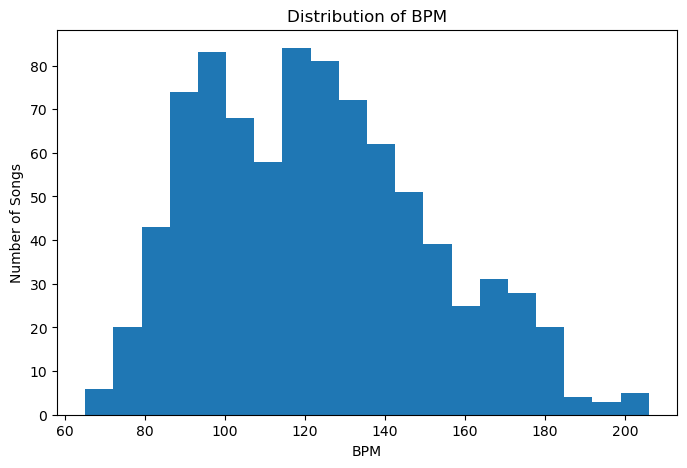

count    857.000000
mean     122.842474
std       28.196567
min       65.000000
25%      100.000000
50%      121.000000
75%      142.000000
max      206.000000
Name: bpm, dtype: float64

In [7]:
import matplotlib.pyplot as plt

#Plot BPM
plt.figure(figsize=(8,5))
plt.hist(spotify['bpm'], bins=20)
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Number of Songs')
plt.show()

spotify['bpm'].describe()

In [ ]:
Most songs fall in the middle of the tempo range instead of being too slow or too fast. 

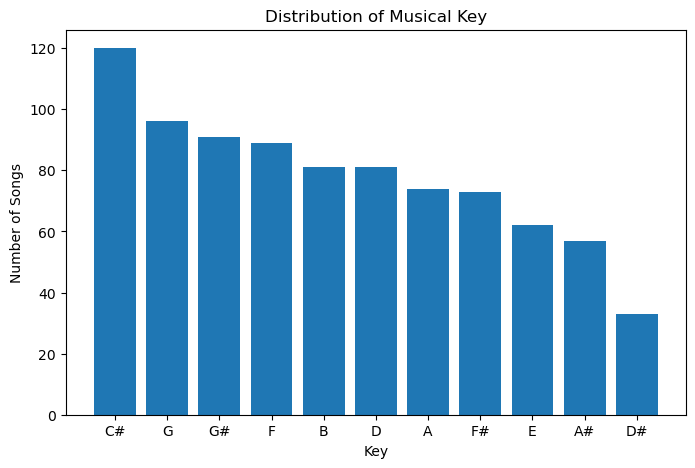

key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      74
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt

#Plot Key
key_counts = spotify['key'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(key_counts.index, key_counts.values)
plt.title('Distribution of Musical Key')
plt.xlabel('Key')
plt.ylabel('Number of Songs')
plt.show()

key_counts

In [ ]:
C# seems to be the most common key in the dataset. A smash hit would definately be in C#. 

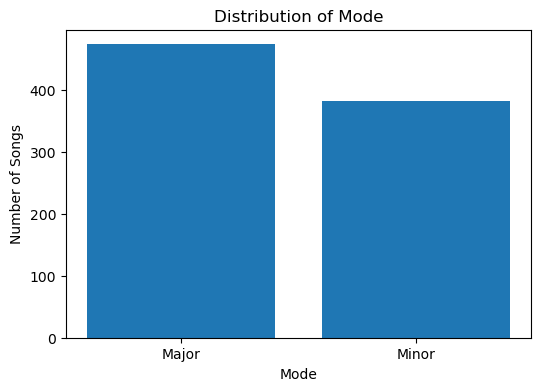

mode
Major    474
Minor    383
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt

#Plot Mode
mode_counts = spotify['mode'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(mode_counts.index, mode_counts.values)
plt.title('Distribution of Mode')
plt.xlabel('Mode')
plt.ylabel('Number of Songs')
plt.show()

mode_counts

In [ ]:
There are more songs in major key rather than minor. 

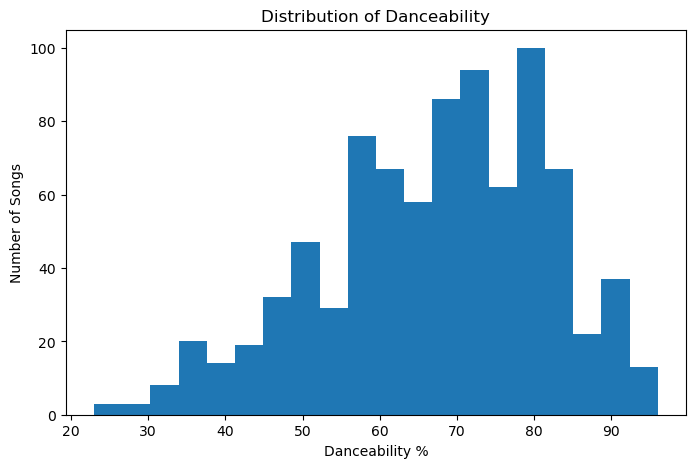

count    857.000000
mean      67.273046
std       14.653159
min       23.000000
25%       57.000000
50%       70.000000
75%       78.000000
max       96.000000
Name: danceability_%, dtype: float64

In [13]:
import matplotlib.pyplot as plt

#plot Danceability
plt.figure(figsize=(8,5))
plt.hist(spotify['danceability_%'], bins=20)
plt.title('Distribution of Danceability')
plt.xlabel('Danceability %')
plt.ylabel('Number of Songs')
plt.show()

spotify['danceability_%'].describe()

In [ ]:
A hit would probably fall more toward the middle as they are higher for danceablilty. 

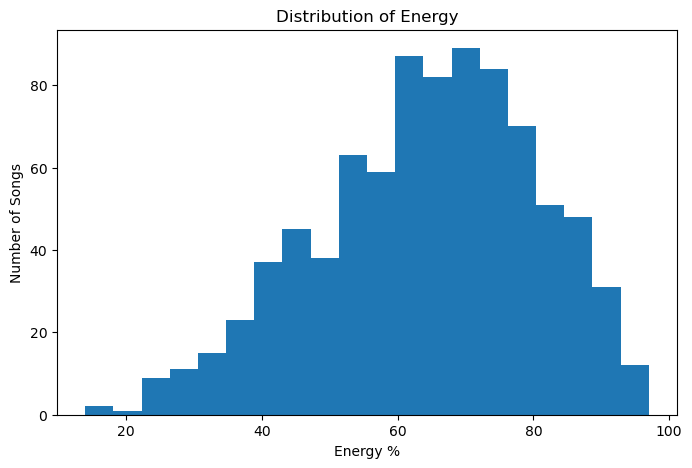

count    857.000000
mean      64.339557
std       16.056348
min       14.000000
25%       53.000000
50%       66.000000
75%       76.000000
max       97.000000
Name: energy_%, dtype: float64

In [10]:
import matplotlib.pyplot as plt

#Plot Energy
plt.figure(figsize=(8,5))
plt.hist(spotify['energy_%'], bins=20)
plt.title('Distribution of Energy')
plt.xlabel('Energy %')
plt.ylabel('Number of Songs')
plt.show()

spotify['energy_%'].describe()

In [ ]:
Energy distribution tends to be higher rather than lower. 

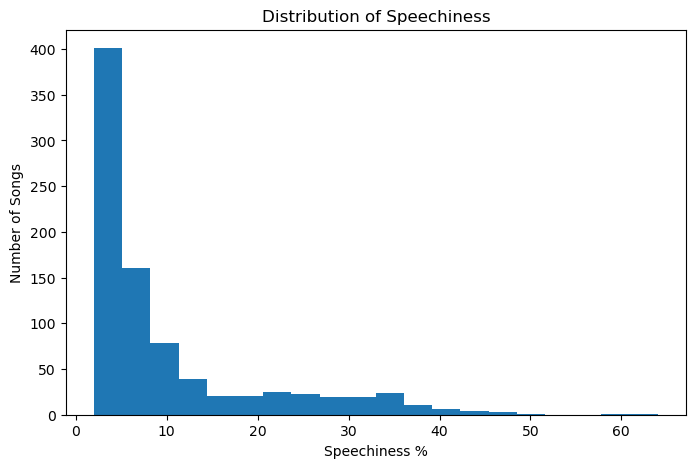

count    857.000000
mean      10.396733
std       10.090890
min        2.000000
25%        4.000000
50%        6.000000
75%       12.000000
max       64.000000
Name: speechiness_%, dtype: float64

In [11]:
import matplotlib.pyplot as plt
#Plot Spechiness
plt.figure(figsize=(8,5))
plt.hist(spotify['speechiness_%'], bins=20)
plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness %')
plt.ylabel('Number of Songs')
plt.show()

spotify['speechiness_%'].describe()

In [ ]:
Most songs don't contain much speech, rather musical lyrics. 

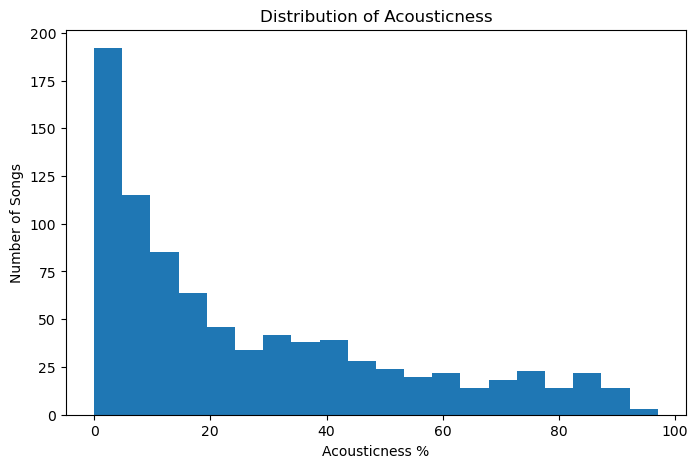

count    857.000000
mean      26.644107
std       25.688111
min        0.000000
25%        5.000000
50%       17.000000
75%       42.000000
max       97.000000
Name: acousticness_%, dtype: float64

In [12]:
import matplotlib.pyplot as plt

#Plot Acousticness
plt.figure(figsize=(8,5))
plt.hist(spotify['acousticness_%'], bins=20)
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness %')
plt.ylabel('Number of Songs')
plt.show()

spotify['acousticness_%'].describe()

In [ ]:
The majority of songs have low to none acousticness.

In [ ]:
A proposed guaranteed smash hit would include a song with a BPM between 120-130, have a key in c#, have a mode of major, have an above average 
danceablility (80%), a high energy level (between 60-80%), have limited speechiness, and hardly any acousticness.

In [15]:
hit_key = spotify['key'].mode()[0]
hit_mode = spotify['mode'].mode()[0]

matches = spotify[
    (spotify['bpm'].between(110, 130)) &
    (spotify['key'] == hit_key) &
    (spotify['mode'] == hit_mode) &
    (spotify['danceability_%'].between(65, 85)) &
    (spotify['energy_%'].between(60, 85)) &
    (spotify['speechiness_%'].between(5, 15)) &
    (spotify['acousticness_%'].between(0, 30))
]

matches[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
         'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].sort_values(
    by='streams', ascending=False
)

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
518,Need To Know,Doja Cat,1.042568e+09,130,C#,Major,66,61,7,30
845,Belly Dancer,"BYOR, Imanbek",3.838360e+08,122,C#,Major,85,80,14,6
778,Dos Mil 16,Bad Bunny,3.384220e+08,130,C#,Major,82,67,5,12


In [ ]:
Dos Mil 16 by Bad Bunny seems to fit within the parameters of the smash hit category. It seems to be pretty popular as it includes 338,422,000 streams.

In [ ]:
Justin Beiber's Baby was a smash hit and a very recognizable popsong. It had a 130 BPM. The acousticness is low as well as the speechiness. 
The danceablilty was high and the song has high energy. Although the song was not in the key of C# it was still a banger. 